# Vortrag 4: Zulassungen an der UC Berkeley 1973

**Kurs:** Wirtschaftsinformatik, Statistik (Kleinklasse HS 2026)
**Datengrundlage:** Tabelle 4 der Aufgabenstellung (Quelle: UCB Admissions)

Aufbau des Notebooks:

1. Vorüberlegungen zur programmtechnischen Umsetzung
2. Daten aus Tabelle 4 erfassen und bereinigen
3. Hilfsfunktionen (Anwendung der Konzepte aus McKinney, Abschnitt 3.2)
4. Aufgabe (b): Darstellung der Verhältnisse, die auf eine Ungerechtigkeit schliessen lassen
5. Aufgabe (c): Vergleich der Verteilungen und stochastische Unabhängigkeit
6. Fazit

## 1. Vorüberlegungen zur programmtechnischen Umsetzung

**Was liegt vor?** Tabelle 4 enthält pro Fachbereich (A bis F) nur *relative* Werte:

* die Zulassungsquote $P(Z \mid F_i, G)$ je Geschlecht $G$ und Fachbereich $F_i$ und
* den Anteil der Bewerbungen je Fachbereich $P(F_i \mid G)$ innerhalb eines Geschlechts.

**Was folgt daraus für den Code?**

* Die Tabelle wird als *Strings* (so wie sie abgedruckt ist, z. B. `"82.4%"`) erfasst und
  mit einer eigenen Funktion in Zahlen umgewandelt. So ist die Datenerfassung nachvollziehbar
  und Tippfehler fallen durch eine Fehlerbehandlung auf.
* Die Gesamtquoten der Zeile *Total* lassen sich mit dem **Satz der totalen Wahrscheinlichkeit**
  aus den Fachbereichswerten nachrechnen: $P(Z \mid G) = \sum_i P(F_i \mid G)\cdot P(Z \mid F_i, G)$.
  Das dient als Plausibilitätskontrolle der erfassten Daten.
* Für die Prüfung der stochastischen Unabhängigkeit braucht man zusätzlich das Verhältnis
  Frauen zu Männern bzw. absolute Häufigkeiten, die in Tabelle 4 fehlen. Wir übernehmen die
  Anzahlen des Originaldatensatzes (Bickel, Hammel & O'Connell 1975, in R als `UCBAdmissions`
  verfügbar; 1 835 Bewerbungen von Frauen, 2 691 von Männern) und prüfen per Code, dass sie
  Tabelle 4 exakt reproduzieren.
* Wiederkehrende Rechenschritte (Quote berechnen, Vierfeldertafel bilden, Unabhängigkeit prüfen,
  Diagramm zeichnen) werden **in Funktionen gekapselt**, damit sie für die Gesamtbetrachtung und
  für jeden Fachbereich identisch angewendet werden (vgl. Faustregel von McKinney: *Code, den man
  mehr als einmal braucht, gehört in eine Funktion*).

**Verwendete Libraries und Begründung**

| Library | Zweck | Begründung |
|---|---|---|
| `pandas` | Tabellen (DataFrame), Gruppieren, Kreuztabellen | Standard für tabellarische Daten in Python (McKinney ist der Autor von pandas); Tabelle 4 ist genau so ein Datensatz |
| `numpy` | Vektorisiertes Rechnen, Runden | Grundlage von pandas; schnelle Rechnung auf ganzen Spalten ohne Schleifen |
| `matplotlib` | Diagramme | In Anaconda enthalten, volle Kontrolle über Farben, Beschriftung und Export als PNG für Ausarbeitung und Folien |
| `scipy.stats` | Chi-Quadrat-Unabhängigkeitstest | Geprüfte Implementierung statt eigener Formel; liefert direkt Teststatistik, p-Wert und erwartete Häufigkeiten |
| `re` (Standardbibliothek) | Bereinigung der Prozent-Strings | Wie im Beispiel `clean_strings` bei McKinney, keine Zusatzinstallation nötig |

Alle Libraries sind in der Anaconda-Distribution bereits enthalten, die im Kurs verwendet wird.

In [1]:
# --- Imports -------------------------------------------------------------
import re                              # reguläre Ausdrücke zum Bereinigen der Strings
from functools import partial          # "Currying" (McKinney 3.2)

import numpy as np                     # numerische Berechnungen
import pandas as pd                    # Tabellen / DataFrames
import matplotlib.pyplot as plt        # Diagramme
from scipy.stats import chi2_contingency   # Chi-Quadrat-Unabhängigkeitstest

# Einheitliches Aussehen aller Diagramme: eine Farbe pro Geschlecht,
# die in jedem Diagramm gleich bleibt (Farbe folgt der Kategorie).
FARBEN = {"Frauen": "#eb6834", "Männer": "#2a78d6"}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#dddddd",
    "font.size": 11,
})
ABB_ORDNER = "abbildungen/"   # hier werden die PNGs für Ausarbeitung und Folien gespeichert

## 2. Daten aus Tabelle 4 erfassen und bereinigen

Die Werte werden exakt so übernommen, wie sie in Tabelle 4 stehen (als Text mit `%`).
Die Bereinigung folgt dem Muster aus McKinney (Abschnitt 3.2, *Funktionen sind Objekte*):
Eine **Liste von Funktionen** wird nacheinander auf jeden Wert angewendet.

In [2]:
# Tabelle 4 wortgetreu als Dictionary: Schlüssel = Spaltenname, Wert = Liste von Strings
tabelle4_roh = {
    "Fachbereich":   ["A", "B", "C", "D", "E", "F"],
    "Quote_Frauen":  ["82.4%", "68.0%", "34.1%", "34.9%", "23.9%", "7.0%"],
    "Quote_Männer":  ["62.1%", "63.0%", "36.9%", "33.1%", "27.7%", "5.9%"],
    "Anteil_Frauen": ["5.9%", "1.4%", "32.3%", "20.4%", "21.4%", "18.6%"],
    "Anteil_Männer": ["30.7%", "20.8%", "12.1%", "15.5%", "7.1%", "13.9%"],
}
# Zeile "Total" aus Tabelle 4 (für die Plausibilitätskontrolle)
TOTAL_QUOTE = {"Frauen": 0.304, "Männer": 0.445}


def entferne_prozentzeichen(wert):
    # Entfernt Prozentzeichen und Leerzeichen, z. B. " 82.4% " -> "82.4"
    return re.sub(r"[%\s]", "", wert)


def in_anteil(wert):
    # Wandelt "82.4" in 0.824 um. Fängt nur ValueError ab (wie attempt_float bei
    # McKinney): ein Tippfehler in der Tabelle soll sichtbar gemeldet werden,
    # statt stillschweigend eine falsche Zahl zu erzeugen.
    try:
        return float(wert) / 100
    except ValueError:
        raise ValueError(f"Ungültiger Tabellenwert: {wert!r}")


# Funktionen sind Objekte: Wir legen die Bereinigungsschritte in einer Liste ab ...
bereinigungs_schritte = [str.strip, entferne_prozentzeichen, in_anteil]


def bereinige(werte, schritte):
    # ... und wenden sie der Reihe nach auf jeden Wert an.
    ergebnis = []
    for wert in werte:
        for funktion in schritte:
            wert = funktion(wert)
        ergebnis.append(wert)
    return ergebnis


# DataFrame aufbauen: Fachbereich bleibt Text, alle anderen Spalten werden bereinigt
tab4 = pd.DataFrame({
    spalte: werte if spalte == "Fachbereich" else bereinige(werte, bereinigungs_schritte)
    for spalte, werte in tabelle4_roh.items()
}).set_index("Fachbereich")
tab4

,Quote_Frauen,Quote_Männer,Anteil_Frauen,Anteil_Männer
Fachbereich,,,,
A,0.824,0.621,0.059,0.307
B,0.680,0.630,0.014,0.208
C,0.341,0.369,0.323,0.121
D,0.349,0.331,0.204,0.155
E,0.239,0.277,0.214,0.071
F,0.070,0.059,0.186,0.139


### Plausibilitätskontrolle mit dem Satz der totalen Wahrscheinlichkeit

$$P(Z \mid G) = \sum_{i=A}^{F} P(F_i \mid G)\cdot P(Z \mid F_i, G)$$

Die Gesamtquote eines Geschlechts ist also ein **gewichteter Mittelwert** der Fachbereichsquoten,
gewichtet mit der Verteilung der Bewerbungen auf die Fachbereiche. Diese Formel ist der Schlüssel
zum Verständnis des ganzen Datensatzes.

In [3]:
def gesamtquote(quoten, anteile):
    # Satz der totalen Wahrscheinlichkeit: Summe über (Anteil * Quote).
    # quoten und anteile sind pandas-Series mit dem Fachbereich als Index.
    return float((quoten * anteile).sum())


for g in ["Frauen", "Männer"]:
    berechnet = gesamtquote(tab4[f"Quote_{g}"], tab4[f"Anteil_{g}"])
    print(f"{g:7s}: berechnet {berechnet:.1%}   laut Tabelle {TOTAL_QUOTE[g]:.1%}")

Frauen : berechnet 30.4%   laut Tabelle 30.4%
Männer : berechnet 44.6%   laut Tabelle 44.5%


Die aus den Fachbereichen berechneten Gesamtquoten stimmen bis auf Rundungsdifferenzen
(max. 0.1 Prozentpunkte, weil Tabelle 4 auf eine Nachkommastelle gerundet ist) mit der Zeile
*Total* überein. Die Daten sind also korrekt erfasst.

### Absolute Häufigkeiten

Für Vierfeldertafeln und den Chi-Quadrat-Test brauchen wir Anzahlen statt Prozentwerten.
Aus den gerundeten Prozenten von Tabelle 4 lassen sich die Anzahlen nicht exakt zurückrechnen
(ein Versuch ergibt z. B. 26 statt 25 Bewerberinnen in Fachbereich B). Wir übernehmen deshalb die
Anzahlen aus dem Originaldatensatz (Bickel et al. 1975, R-Datensatz `UCBAdmissions`) und
**prüfen, dass sie Tabelle 4 exakt reproduzieren**.

In [4]:
# Originaldaten: (zugelassen, abgelehnt) je Geschlecht und Fachbereich
ORIGINAL = {
    "Frauen": {"A": (89, 19),   "B": (17, 8),    "C": (202, 391),
               "D": (131, 244), "E": (94, 299),  "F": (24, 317)},
    "Männer": {"A": (512, 313), "B": (353, 207), "C": (120, 205),
               "D": (138, 279), "E": (53, 138),  "F": (22, 351)},
}


def kennzahlen(zugelassen, abgelehnt, total_bewerbungen):
    # Gibt ZWEI Werte zurück (eigentlich ein Tupel, vgl. "Mehrere Rückgabewerte"):
    # die Zulassungsquote und den Anteil an allen Bewerbungen des Geschlechts.
    bewerbungen = zugelassen + abgelehnt
    return zugelassen / bewerbungen, bewerbungen / total_bewerbungen


# "Langes" Datenformat: eine Zeile pro Fachbereich x Geschlecht x Entscheid
zeilen = []
for g, fachbereiche in ORIGINAL.items():
    for fb_name, (zul, abg) in fachbereiche.items():        # Tupel direkt entpacken
        zeilen.append({"Fachbereich": fb_name, "Geschlecht": g,
                       "Entscheid": "zugelassen", "Anzahl": zul})
        zeilen.append({"Fachbereich": fb_name, "Geschlecht": g,
                       "Entscheid": "abgelehnt", "Anzahl": abg})
daten = pd.DataFrame(zeilen)

# Gegenprobe gegen Tabelle 4 (auf eine Nachkommastelle in Prozent gerundet)
abweichungen = 0
for g, fachbereiche in ORIGINAL.items():
    n_g = sum(zul + abg for zul, abg in fachbereiche.values())
    for fb_name, (zul, abg) in fachbereiche.items():
        quote, anteil = kennzahlen(zul, abg, n_g)
        # Toleranz: halbe Rundungseinheit von Tabelle 4 (0.05 Prozentpunkte)
        if abs(quote - tab4.loc[fb_name, f"Quote_{g}"]) > 0.0005 or \
           abs(anteil - tab4.loc[fb_name, f"Anteil_{g}"]) > 0.0005:
            abweichungen += 1
            print("Abweichung:", g, fb_name, quote, anteil)
    print(f"{g}: {n_g} Bewerbungen")
print("Abweichungen zu Tabelle 4:", abweichungen)

# Kreuztabelle der Anzahlen zur Übersicht
daten.pivot_table(index="Fachbereich", columns=["Geschlecht", "Entscheid"],
                  values="Anzahl", aggfunc="sum")

Frauen: 1835 Bewerbungen
Männer: 2691 Bewerbungen
Abweichungen zu Tabelle 4: 0


Geschlecht     Frauen               Männer           
Entscheid   abgelehnt zugelassen abgelehnt zugelassen
Fachbereich                                          
A                  19         89       313        512
B                   8         17       207        353
C                 391        202       205        120
D                 244        131       279        138
E                 299         94       138         53
F                 317         24       351         22

## 3. Hilfsfunktionen für die Analyse

Die folgenden Funktionen werden sowohl für die Gesamtbetrachtung als auch für jeden
Fachbereich verwendet. Sie zeigen die Konzepte aus McKinney 3.2:
Positions- und Keyword-Argumente mit Standardwert, Rückgabe eines Dictionarys,
Lambda-Funktionen, Currying mit `partial` und einen Generator mit `yield`.

In [5]:
def vierfeldertafel(daten, fachbereich=None):
    # Erstellt die 2x2-Tafel Geschlecht x Entscheid.
    # fachbereich ist ein Keyword-Argument mit Standardwert None:
    #   None -> alle Fachbereiche zusammen, sonst nur der gewählte Fachbereich.
    if fachbereich is not None:
        daten = daten[daten["Fachbereich"] == fachbereich]
    return daten.pivot_table(index="Geschlecht", columns="Entscheid",
                             values="Anzahl", aggfunc="sum")[["zugelassen", "abgelehnt"]]


def pruefe_unabhaengigkeit(tafel, alpha=0.05):
    # Prüft, ob die Ereignisse Z = "zugelassen" und W = "weiblich" stochastisch
    # unabhängig sind. Rückgabe als Dictionary (McKinney: attraktive Alternative zu
    # mehreren Rückgabewerten, weil die Werte über ihren Namen ansprechbar sind).
    n = tafel.values.sum()
    p_w = tafel.loc["Frauen"].sum() / n                 # P(W)
    p_z = tafel["zugelassen"].sum() / n                 # P(Z)
    p_z_und_w = tafel.loc["Frauen", "zugelassen"] / n   # P(Z ∩ W)
    chi2, p_wert, _, _ = chi2_contingency(tafel.values, correction=False)
    return {
        "n": int(n),
        "P(Z)": p_z,
        "P(Z|W)": tafel.loc["Frauen", "zugelassen"] / tafel.loc["Frauen"].sum(),
        "P(Z|M)": tafel.loc["Männer", "zugelassen"] / tafel.loc["Männer"].sum(),
        "P(Z∩W)": p_z_und_w,
        "P(Z)·P(W)": p_z * p_w,
        "Chi2": chi2,
        "p-Wert": p_wert,
        "unabhängig?": "ja (H0 nicht verworfen)" if p_wert >= alpha else "nein (H0 verworfen)",
    }


def ergebnisse_je_fachbereich(daten, fachbereiche):
    # Generator: liefert die Ergebnisse Fachbereich für Fachbereich (Lazy Evaluation),
    # erst wenn sie z. B. von pd.DataFrame angefordert werden.
    for fb in fachbereiche:
        yield fb, pruefe_unabhaengigkeit(vierfeldertafel(daten, fachbereich=fb))


# Lambda-Funktionen für die Formatierung der Ausgaben
prozent = lambda x: f"{x:.1%}"
dezimal = lambda x: f"{x:.4f}"

# Currying: Eine Variante des Tests mit strengerem Signifikanzniveau 1 %
pruefe_streng = partial(pruefe_unabhaengigkeit, alpha=0.01)

## 4. Aufgabe (b): Darstellung der Verhältnisse

Ein Betrachter soll *schnell* erkennen, weshalb das Zulassungsverfahren ungerecht wirkt.
Dafür reicht ein einziger Vergleich: die **Gesamtzulassungsquote von Frauen und Männern**.
Ein Balkendiagramm mit gemeinsamer Nullachse ist dafür die klarste Form, weil Längen
direkt verglichen werden können. Die Differenz in Prozentpunkten wird direkt eingezeichnet.

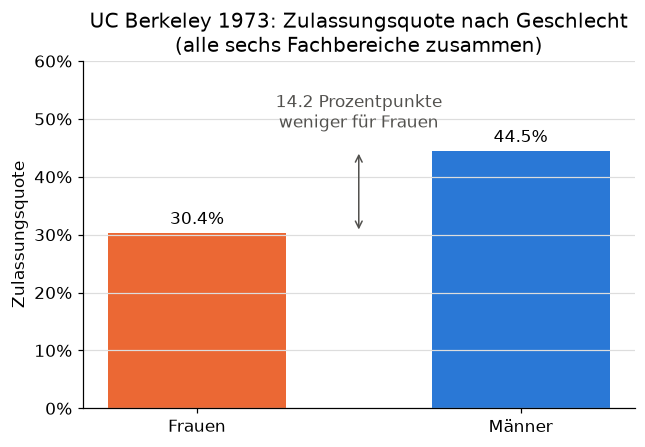

In [6]:
def balken_beschriften(ax, balken, format_funktion=prozent):
    # Schreibt den Wert über jeden Balken. Die Formatierung wird als Funktion
    # übergeben (Funktionen als Argumente anderer Funktionen).
    for b in balken:
        ax.annotate(format_funktion(b.get_height()),
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")


gesamt = pruefe_unabhaengigkeit(vierfeldertafel(daten))
quoten_gesamt = {"Frauen": gesamt["P(Z|W)"], "Männer": gesamt["P(Z|M)"]}

fig, ax = plt.subplots(figsize=(6, 4.2))
balken = ax.bar(list(quoten_gesamt), list(quoten_gesamt.values()), width=0.55,
                color=[FARBEN[g] for g in quoten_gesamt])
balken_beschriften(ax, balken)
differenz = quoten_gesamt["Männer"] - quoten_gesamt["Frauen"]
# Differenz als Klammer zwischen den beiden Balkenhöhen einzeichnen
ax.annotate("", xy=(0.5, quoten_gesamt["Frauen"]), xytext=(0.5, quoten_gesamt["Männer"]),
            arrowprops=dict(arrowstyle="<->", color="#52514e"))
ax.text(0.5, quoten_gesamt["Männer"] + 0.04,
        f"{differenz * 100:.1f} Prozentpunkte\nweniger für Frauen", ha="center", color="#52514e")
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_ylabel("Zulassungsquote")
ax.set_title("UC Berkeley 1973: Zulassungsquote nach Geschlecht\n(alle sechs Fachbereiche zusammen)")
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb1_gesamtquote.png", dpi=200)
plt.show()

In [7]:
# Dasselbe als Zahlen: Wie viele Frauen wären bei der Quote der Männer zugelassen worden?
n_frauen = int(daten.loc[daten.Geschlecht == "Frauen", "Anzahl"].sum())
print("Zugelassene Frauen tatsächlich:          ",
      round(n_frauen * quoten_gesamt["Frauen"]))
print("Zugelassene Frauen bei Männerquote:      ",
      round(n_frauen * quoten_gesamt["Männer"]))
print("Chancenverhältnis Männer/Frauen (Quote): ",
      f"{quoten_gesamt['Männer'] / quoten_gesamt['Frauen']:.2f}")

Zugelassene Frauen tatsächlich:           557
Zugelassene Frauen bei Männerquote:       817
Chancenverhältnis Männer/Frauen (Quote):  1.47


**Zwischenfazit (b):** Männer wurden mit 44.5 % deutlich häufiger zugelassen als Frauen mit
30.4 %. Das sind 14.1 Prozentpunkte bzw. eine rund 1.46-mal so hohe Quote. Auf den ersten Blick
spricht das für eine Benachteiligung der Frauen. Ob dieser Schluss richtig ist, klärt Aufgabe (c).

## 5. Aufgabe (c): Vergleich der Verteilungen

### 5.1 Zulassungsquoten je Fachbereich

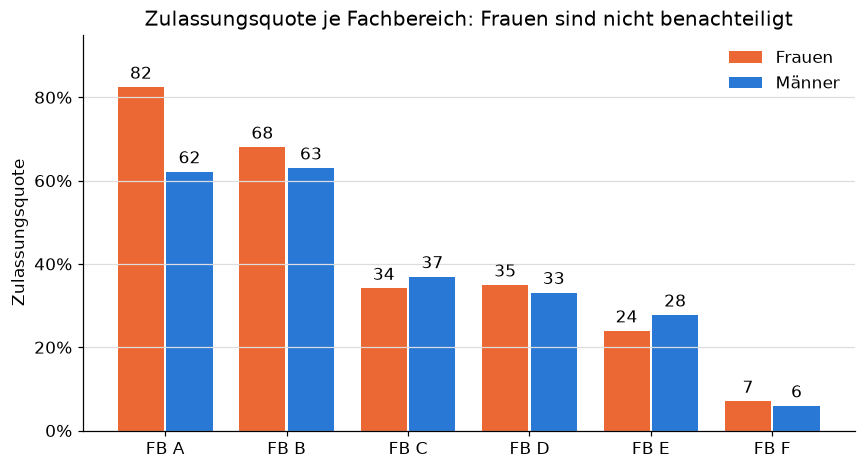

In [8]:
def gruppiertes_balkendiagramm(tab, spalten_praefix, titel, ylabel, dateiname, ylim=None):
    # Zeichnet für jeden Fachbereich einen Frauen- und einen Männerbalken.
    # Wird für Quoten UND Anteile verwendet -> eine Funktion statt doppeltem Code.
    x = np.arange(len(tab.index))
    breite = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.4))
    for i, g in enumerate(["Frauen", "Männer"]):
        balken = ax.bar(x + (i - 0.5) * (breite + 0.02), tab[f"{spalten_praefix}_{g}"],
                        width=breite, color=FARBEN[g], label=g)
        balken_beschriften(ax, balken, format_funktion=lambda v: f"{v * 100:.0f}")
    ax.set_xticks(x, [f"FB {fb}" for fb in tab.index])
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(titel)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ABB_ORDNER + dateiname, dpi=200)
    plt.show()


gruppiertes_balkendiagramm(tab4, "Quote",
    "Zulassungsquote je Fachbereich: Frauen sind nicht benachteiligt",
    "Zulassungsquote", "abb2_quote_fachbereich.png", ylim=(0, 0.95))

In [9]:
# Differenz Frauen minus Männer je Fachbereich (in Prozentpunkten)
diff = ((tab4["Quote_Frauen"] - tab4["Quote_Männer"]) * 100).round(1)
print(diff.to_string())
print("Fachbereiche, in denen Frauen eine höhere Quote haben:", list(diff[diff > 0].index))

Fachbereich
A    20.3
B     5.0
C    -2.8
D     1.8
E    -3.8
F     1.1
Fachbereiche, in denen Frauen eine höhere Quote haben: ['A', 'B', 'D', 'F']


### 5.2 Verteilung der Bewerbungen auf die Fachbereiche

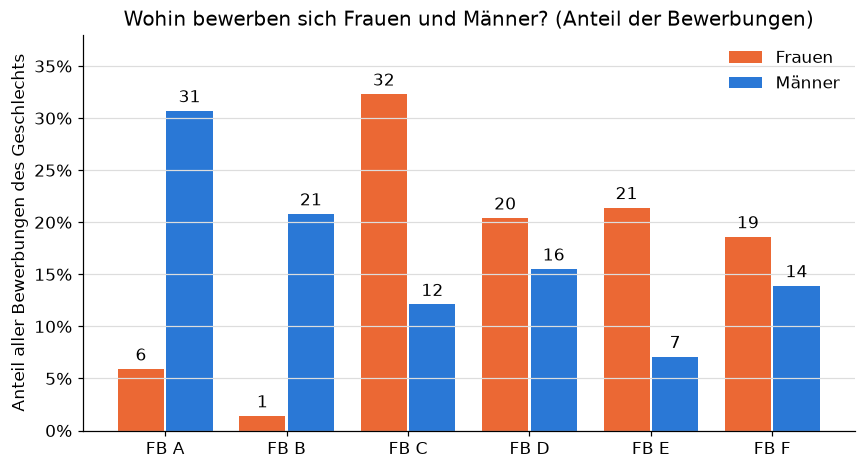

In [10]:
gruppiertes_balkendiagramm(tab4, "Anteil",
    "Wohin bewerben sich Frauen und Männer? (Anteil der Bewerbungen)",
    "Anteil aller Bewerbungen des Geschlechts", "abb3_anteil_fachbereich.png", ylim=(0, 0.38))

### 5.3 Zusammenhang: Frauen bewerben sich häufiger in selektiven Fachbereichen

Pro Fachbereich wird die Gesamtzulassungsquote (beide Geschlechter) dem Frauenanteil
unter den Bewerbungen gegenübergestellt. Die Punktfläche ist proportional zur Anzahl Bewerbungen.

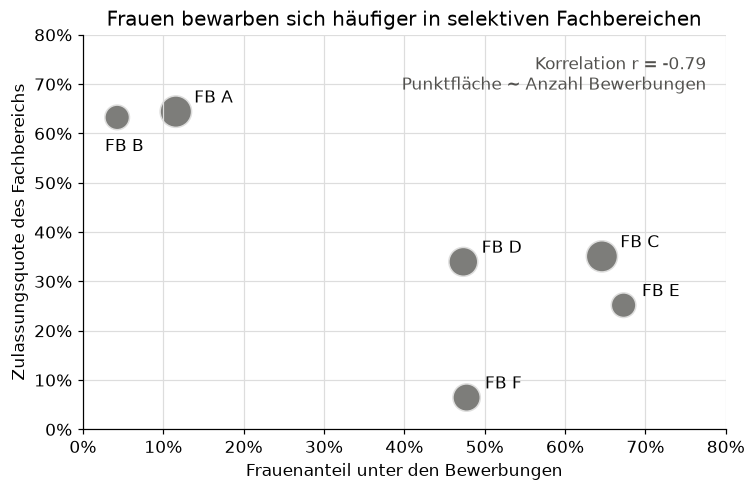

Entscheid,Bewerbungen,Quote_gesamt,Frauenanteil
Fachbereich,,,
A,933,64.4%,11.6%
B,585,63.2%,4.3%
C,918,35.1%,64.6%
D,792,34.0%,47.3%
E,584,25.2%,67.3%
F,714,6.4%,47.8%


In [11]:
# Kennzahlen je Fachbereich aus den Anzahlen
fb = daten.pivot_table(index="Fachbereich", columns="Entscheid", values="Anzahl", aggfunc="sum")
fb["Bewerbungen"] = fb["zugelassen"] + fb["abgelehnt"]
fb["Quote_gesamt"] = fb["zugelassen"] / fb["Bewerbungen"]
fb["Frauenanteil"] = (daten[daten.Geschlecht == "Frauen"]
                      .groupby("Fachbereich")["Anzahl"].sum() / fb["Bewerbungen"])

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(fb["Frauenanteil"], fb["Quote_gesamt"], s=fb["Bewerbungen"] / 2,
           color="#52514e", alpha=0.75, edgecolor="white", linewidth=2)
for name, zeile in fb.iterrows():
    # FB B liegt dicht neben FB A -> Beschriftung dort nach unten verschieben
    versatz = (-8, -22) if name == "B" else (12, 6)
    ax.annotate(f"FB {name}", (zeile["Frauenanteil"], zeile["Quote_gesamt"]),
                xytext=versatz, textcoords="offset points")
r = np.corrcoef(fb["Frauenanteil"], fb["Quote_gesamt"])[0, 1]
ax.set_xlim(0, 0.8); ax.set_ylim(0, 0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Frauenanteil unter den Bewerbungen")
ax.set_ylabel("Zulassungsquote des Fachbereichs")
ax.set_title("Frauen bewarben sich häufiger in selektiven Fachbereichen")
ax.text(0.97, 0.95, f"Korrelation r = {r:.2f}\nPunktfläche ~ Anzahl Bewerbungen",
        transform=ax.transAxes, ha="right", va="top", color="#52514e")
ax.grid(True, axis="both")
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb4_selektivitaet.png", dpi=200)
plt.show()
fb[["Bewerbungen", "Quote_gesamt", "Frauenanteil"]].style.format(
    {"Quote_gesamt": prozent, "Frauenanteil": prozent})

### 5.4 Standardisierung: Was wäre bei gleicher Fachbereichswahl?

Wir setzen in die Formel der totalen Wahrscheinlichkeit für **beide** Geschlechter dieselben
Gewichte ein, nämlich die Verteilung *aller* Bewerbungen auf die Fachbereiche. So bleibt nur noch
der Unterschied in den Quoten innerhalb der Fachbereiche übrig.

       tatsächlich (eigene Fachbereichswahl)  \
Frauen                                 30.4%   
Männer                                 44.5%   

       standardisiert (gleiche Fachbereichswahl)  
Frauen                                     43.0%  
Männer                                     38.7%  


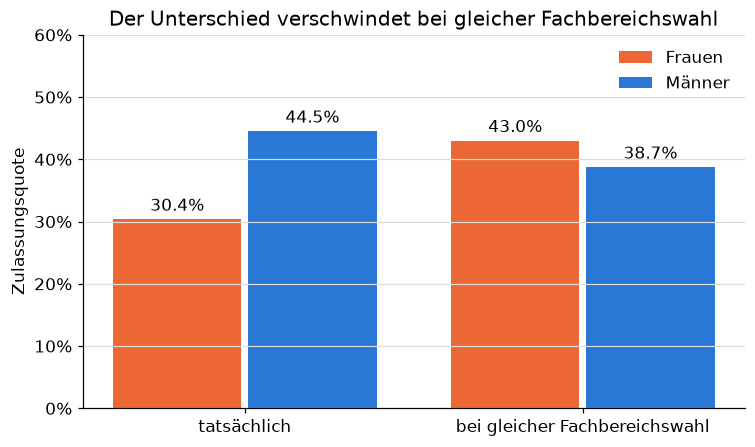

In [12]:
gewichte_alle = fb["Bewerbungen"] / fb["Bewerbungen"].sum()   # gemeinsame Fachbereichsverteilung

# Exakte Quoten und Anteile je Geschlecht aus den Anzahlen (statt der gerundeten Tabelle 4)
bew_g = daten.pivot_table(index="Fachbereich", columns="Geschlecht", values="Anzahl", aggfunc="sum")
zul_g = daten[daten.Entscheid == "zugelassen"].pivot_table(
    index="Fachbereich", columns="Geschlecht", values="Anzahl", aggfunc="sum")
quote_g = zul_g / bew_g                 # P(Z | Fachbereich, Geschlecht)
anteil_g = bew_g / bew_g.sum()          # P(Fachbereich | Geschlecht)

# Dieselbe Funktion gesamtquote, nur mit unterschiedlichen Gewichten
vergleich = pd.DataFrame({
    "tatsächlich (eigene Fachbereichswahl)": {
        g: gesamtquote(quote_g[g], anteil_g[g]) for g in ["Frauen", "Männer"]},
    "standardisiert (gleiche Fachbereichswahl)": {
        g: gesamtquote(quote_g[g], gewichte_alle) for g in ["Frauen", "Männer"]},
})
print(vergleich.map(prozent))

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(2)
for i, g in enumerate(["Frauen", "Männer"]):
    balken = ax.bar(x + (i - 0.5) * 0.4, vergleich.loc[g], width=0.38, color=FARBEN[g], label=g)
    balken_beschriften(ax, balken)
ax.set_xticks(x, ["tatsächlich", "bei gleicher Fachbereichswahl"])
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_ylim(0, 0.6)
ax.set_ylabel("Zulassungsquote")
ax.set_title("Der Unterschied verschwindet bei gleicher Fachbereichswahl")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb5_standardisiert.png", dpi=200)
plt.show()

### 5.5 Stochastische Unabhängigkeit

Zwei Ereignisse $A$ und $B$ sind stochastisch unabhängig, falls
$P(A \mid B) = P(A)$ bzw. gleichwertig $P(A \cap B) = P(A)\cdot P(B)$ (Folienskript Teil 3).
Hier: $Z$ = "zugelassen", $W$ = "Bewerbung einer Frau".

Wir prüfen die Bedingung zuerst **über alle Fachbereiche** (Vierfeldertafel), danach **innerhalb
jedes Fachbereichs** (bedingte Unabhängigkeit gegeben Fachbereich). Ergänzend wird mit dem
Chi-Quadrat-Unabhängigkeitstest geprüft, ob die Abweichung von $P(Z\cap W) = P(Z)\,P(W)$ grösser
ist, als per Zufall zu erwarten wäre ($H_0$: unabhängig, $\alpha = 5\,\%$).

In [13]:
print("Vierfeldertafel, alle Fachbereiche:")
print(vierfeldertafel(daten), "\n")
print(f"P(Z)       = {gesamt['P(Z)']:.4f}")
print(f"P(Z|W)     = {gesamt['P(Z|W)']:.4f}   P(Z|M) = {gesamt['P(Z|M)']:.4f}")
print(f"P(Z∩W)     = {gesamt['P(Z∩W)']:.4f}")
print(f"P(Z)·P(W)  = {gesamt['P(Z)·P(W)']:.4f}")
print(f"Chi2 = {gesamt['Chi2']:.1f}, p-Wert = {gesamt['p-Wert']:.1e} -> unabhängig? {gesamt['unabhängig?']}")

Vierfeldertafel, alle Fachbereiche:
Entscheid   zugelassen  abgelehnt
Geschlecht                       
Frauen             557       1278
Männer            1198       1493 

P(Z)       = 0.3878
P(Z|W)     = 0.3035   P(Z|M) = 0.4452
P(Z∩W)     = 0.1231
P(Z)·P(W)  = 0.1572
Chi2 = 92.2, p-Wert = 7.8e-22 -> unabhängig? nein (H0 verworfen)


In [14]:
# Dieselbe Prüfung für jeden Fachbereich: der Generator liefert (Fachbereich, Ergebnis)-Paare
je_fb = pd.DataFrame(dict(ergebnisse_je_fachbereich(daten, tab4.index))).T
je_fb[["n", "P(Z|W)", "P(Z|M)", "P(Z∩W)", "P(Z)·P(W)", "Chi2", "p-Wert", "unabhängig?"]].style.format({
    "P(Z|W)": prozent, "P(Z|M)": prozent, "P(Z∩W)": dezimal, "P(Z)·P(W)": dezimal,
    "Chi2": "{:.2f}", "p-Wert": "{:.4f}"})

,n,P(Z|W),P(Z|M),P(Z∩W),P(Z)·P(W),Chi2,p-Wert,unabhängig?
A,933,82.4%,62.1%,0.0954,0.0746,17.25,0.0000,nein (H0 verworfen)
B,585,68.0%,63.0%,0.0291,0.0270,0.25,0.6145,ja (H0 nicht verworfen)
C,918,34.1%,36.9%,0.2200,0.2266,0.75,0.3854,ja (H0 nicht verworfen)
D,792,34.9%,33.1%,0.1654,0.1608,0.30,0.5852,ja (H0 nicht verworfen)
E,584,23.9%,27.7%,0.1610,0.1694,1.00,0.3171,ja (H0 nicht verworfen)
F,714,7.0%,5.9%,0.0336,0.0308,0.38,0.5354,ja (H0 nicht verworfen)


In [15]:
# Robustheit: Ändert sich das Ergebnis bei alpha = 1 % (Currying mit partial)?
for name in tab4.index:
    print(f"FB {name}:", pruefe_streng(vierfeldertafel(daten, fachbereich=name))["unabhängig?"])

FB A: nein (H0 verworfen)
FB B: ja (H0 nicht verworfen)
FB C: ja (H0 nicht verworfen)
FB D: ja (H0 nicht verworfen)
FB E: ja (H0 nicht verworfen)
FB F: ja (H0 nicht verworfen)


### 5.6 Wodurch entsteht die Abhängigkeit? Fachbereich als Drittvariable

Das Geschlecht hängt stark mit der Wahl des Fachbereichs zusammen, und der Fachbereich hängt
stark mit der Zulassungswahrscheinlichkeit zusammen. Beides lässt sich mit demselben Test prüfen.

In [16]:
geschlecht_x_fb = daten.pivot_table(index="Fachbereich", columns="Geschlecht",
                                    values="Anzahl", aggfunc="sum")
entscheid_x_fb = fb[["zugelassen", "abgelehnt"]]

for titel, tafel in [("Geschlecht vs. Fachbereich", geschlecht_x_fb),
                     ("Entscheid vs. Fachbereich", entscheid_x_fb)]:
    chi2, p, dof, _ = chi2_contingency(tafel.values)
    print(f"{titel:28s} Chi2 = {chi2:7.1f}, df = {dof}, p = {p:.1e}")

Geschlecht vs. Fachbereich   Chi2 =  1068.4, df = 5, p = 9.4e-229
Entscheid vs. Fachbereich    Chi2 =   778.9, df = 5, p = 4.2e-166


## 6. Fazit

* **Aggregiert** (Aufgabe b): Frauen 30.4 % gegenüber Männern 44.5 %. Zulassung und Geschlecht
  sind stochastisch **abhängig** ($P(Z\cap W) \neq P(Z)\,P(W)$, Chi-Quadrat hoch signifikant).
* **Je Fachbereich** (Aufgabe c): In 4 von 6 Fachbereichen haben Frauen die höhere Quote. Nur in
  Fachbereich A ist die Abhängigkeit signifikant, und zwar *zugunsten* der Frauen. In B bis F kann
  die Unabhängigkeit von Zulassung und Geschlecht nicht verworfen werden.
* **Ursache:** Frauen bewarben sich überwiegend in Fachbereichen mit tiefen Zulassungsquoten (C bis F),
  Männer überwiegend in A und B mit hohen Quoten. Die Gesamtquote ist ein gewichteter Mittelwert,
  und die unterschiedlichen Gewichte erzeugen den Unterschied (**Simpson-Paradoxon**).
  Bei gleicher Fachbereichswahl läge die Quote der Frauen sogar leicht höher.
* Die *scheinbare* Ungerechtigkeit ist deshalb kein Beleg für eine Diskriminierung durch die
  Zulassungsstellen. Offen bleibt, *warum* Frauen sich in selektiveren (oft schlechter finanzierten)
  Fachbereichen bewarben. Das lässt sich mit diesen Daten nicht beantworten.